In [3]:
import numpy as np

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym

class PGNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4,8)
    self.fc2 = nn.Linear(8,4)
    self.fc3 = nn.Linear(4,2)

  def forward(self,a):
    a = self.fc1(a)
    a = torch.relu(a)
    a = self.fc2(a)
    a = torch.relu(a)
    a = self.fc3(a)
    return a

class ValueNetwork(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(4,8)
    self.fc2 = nn.Linear(8,4)
    self.fc3 = nn.Linear(4,1)

  def forward(self,a):
    a = self.fc1(a)
    a = torch.relu(a)
    a = self.fc2(a)
    a = torch.relu(a)
    a = self.fc3(a)
    return a

In [ ]:
class PGBaseline:
  def __init__(self,env,policy,value,lr=0.003):
    self.env = env
    self.policy = policy
    self.value = value
    self.policy_optimizer = optim.Adam(self.policy.parameters(),lr=lr)
    self.value_optimizer = optim.Adam(self.value.parameters(),lr=lr)

  def compute_policy_loss(self,log_probs,advantage):
    return -(log_probs * advantage.detach()).mean()

  def compute_value_loss(self,advantage):
    return (advantage**2).mean()

  def get_return(self,rewards,gamma=0.99):
    n = len(rewards)
    rtgs = np.zeros_like(rewards,dtype=np.float32)
    for i in reversed(range(n)):
        rtgs[i] = rewards[i] + (gamma*rtgs[i+1] if i+1 < n else 0)
    return rtgs

  def train_one_epoch(self,batch_size=5000):
    batch_log_probs = []
    batch_values = []
    batch_returns = []

    episode_rewards = []
    epoch_episode_rewards = []

    obs, _ = self.env.reset()

    done, truncated = False, False

    while True:
      obs = torch.tensor(obs,dtype=torch.float32)
      logits = self.policy(obs)
      dist = torch.distributions.Categorical(logits=logits)
      action = dist.sample()
      log_prob = dist.log_prob(action)
      value = self.value(obs)

      obs, reward, done, truncated, _ = self.env.step(action.item())

      episode_rewards.append(reward)
      batch_log_probs.append(log_prob)
      batch_values.append(value)

      if done or truncated:
        obs, _ = self.env.reset()
        done, truncated = False, False

        epoch_episode_rewards.append(sum(episode_rewards))

        batch_returns.extend(self.get_return(episode_rewards))
        episode_rewards = []
        if len(batch_returns) > batch_size:
          break

    batch_values = torch.stack(batch_values)
    batch_log_probs = torch.stack(batch_log_probs)
    batch_returns = torch.tensor(batch_returns,dtype=torch.float32)
    batch_advantage = batch_returns - batch_values
    policy_loss = self.compute_policy_loss(batch_log_probs,batch_advantage)
    value_loss = self.compute_value_loss(batch_advantage)

    self.policy_optimizer.zero_grad()
    policy_loss.backward()
    self.policy_optimizer.step()

    self.value_optimizer.zero_grad()
    value_loss.backward()
    self.value_optimizer.step()

    return epoch_episode_rewards

  def train(self, epoch=50):
    history = []

    for i in range(epoch):

        episode_rewards = self.train_one_epoch()

        history.extend(episode_rewards)

        print(
            f"Epoch {i+1:3d} | "
            f"Episodes: {len(episode_rewards):3d} | "
            f"Mean Reward: {np.mean(episode_rewards):.2f}"
        )

    return history

In [11]:
class PGBaselineVecEnv:
  def __init__(self,envs,num_envs,policy,value,lr=0.003):
    self.envs = envs
    self.num_envs = num_envs
    self.policy = policy
    self.value = value
    self.policy_optimizer = optim.Adam(self.policy.parameters(),lr=lr)
    self.value_optimizer = optim.Adam(self.value.parameters(),lr=lr)

  def compute_policy_loss(self,log_probs,advantage):
    return -(log_probs * advantage.detach()).mean()

  def compute_value_loss(self,advantage):
    return (advantage**2).mean()

  def get_return(self,rewards,gamma=0.99):
    n = len(rewards)
    rtgs = np.zeros_like(rewards,dtype=np.float32)
    for i in reversed(range(n)):
        rtgs[i] = rewards[i] + (gamma*rtgs[i+1] if i+1 < n else 0)
    return rtgs

  def train_one_epoch(self,batch_size=5000):
    batch_log_probs = []
    batch_values = []
    batch_returns = []

    episode_rewards = [[] for i in range(self.num_envs)]
    episode_log_probs = [ [] for i in range(self.num_envs)]
    episode_values =[[] for i in range(self.num_envs)]
    epoch_episode_rewards = []

    obs, _ = self.envs.reset()

    while len(batch_returns)<=batch_size:

      obs = torch.tensor(obs,dtype=torch.float32)
      logits = self.policy(obs)
      dist = torch.distributions.Categorical(logits=logits)
      action = dist.sample()
      log_prob = dist.log_prob(action)
      value = self.value(obs)

      obs, reward, terminated, truncated, _ = self.envs.step(action.numpy())

      done = np.logical_or(terminated,truncated)

      for i in range(self.num_envs):
        episode_rewards[i].append(reward[i])
        episode_log_probs[i].append(log_prob[i])
        episode_values[i].append(value[i])

      for i in range(self.num_envs):
        if done[i]:
          batch_returns.extend(self.get_return(episode_rewards[i]))
          batch_log_probs.extend(episode_log_probs[i])
          batch_values.extend(episode_values[i])

          epoch_episode_rewards.append(sum(episode_rewards[i]))

          episode_rewards[i]=[]
          episode_log_probs[i]=[]
          episode_values[i]=[]

    batch_values = torch.stack(batch_values)
    batch_log_probs = torch.stack(batch_log_probs)
    batch_returns = torch.tensor(batch_returns,dtype=torch.float32)
    batch_baseline = batch_returns - batch_values
    policy_loss = self.compute_policy_loss(batch_log_probs,batch_baseline)
    value_loss = self.compute_value_loss(batch_baseline)

    self.policy_optimizer.zero_grad()
    policy_loss.backward()
    self.policy_optimizer.step()

    self.value_optimizer.zero_grad()
    value_loss.backward()
    self.value_optimizer.step()

    return epoch_episode_rewards

  def train(self, epoch=50):
    history = []

    for i in range(epoch):

        episode_rewards = self.train_one_epoch()

        history.extend(episode_rewards)

        print(
            f"Epoch {i+1:3d} | "
            f"Episodes: {len(episode_rewards):3d} | "
            f"Mean Reward: {np.mean(episode_rewards):.2f}"
        )

    return history

In [13]:
num_envs = 8
envs = gym.make_vec('CartPole-v1',num_envs=8,vectorization_mode='sync')
envs = gym.vector.SyncVectorEnv([
    lambda: gym.make('CartPole-v1',render_mode='rgb_array')
    for _ in range(num_envs)
])

agent_vec = PGBaselineVecEnv(envs=envs,num_envs=num_envs,policy=PGNetwork(),value=ValueNetwork(),lr=0.08)
rewards = agent_vec.train(epoch=50)

Epoch   1 | Episodes: 227 | Mean Reward: 21.14
Epoch   2 | Episodes: 216 | Mean Reward: 22.32
Epoch   3 | Episodes: 205 | Mean Reward: 23.43
Epoch   4 | Episodes: 205 | Mean Reward: 23.55
Epoch   5 | Episodes: 184 | Mean Reward: 26.50
Epoch   6 | Episodes: 161 | Mean Reward: 30.28
Epoch   7 | Episodes: 144 | Mean Reward: 33.81
Epoch   8 | Episodes: 117 | Mean Reward: 41.91
Epoch   9 | Episodes: 102 | Mean Reward: 48.20
Epoch  10 | Episodes:  97 | Mean Reward: 51.77
Epoch  11 | Episodes:  87 | Mean Reward: 58.23
Epoch  12 | Episodes:  82 | Mean Reward: 60.91
Epoch  13 | Episodes:  78 | Mean Reward: 64.68
Epoch  14 | Episodes:  67 | Mean Reward: 73.85
Epoch  15 | Episodes:  67 | Mean Reward: 74.01
Epoch  16 | Episodes:  58 | Mean Reward: 86.19
Epoch  17 | Episodes:  49 | Mean Reward: 101.94
Epoch  18 | Episodes:  47 | Mean Reward: 106.98
Epoch  19 | Episodes:  34 | Mean Reward: 147.00
Epoch  20 | Episodes:  34 | Mean Reward: 147.35
Epoch  21 | Episodes:  27 | Mean Reward: 188.26
Epoch  2

In [ ]:
agent = PGBaseline(env=gym.make("CartPole-v1"),policy=PGNetwork(),value=ValueNetwork(),lr=0.08)
rewards = agent.train(epoch=50)

Epoch   1 | Episodes: 228 | Mean Reward: 21.95
Epoch   2 | Episodes: 229 | Mean Reward: 21.87
Epoch   3 | Episodes: 219 | Mean Reward: 22.91
Epoch   4 | Episodes: 180 | Mean Reward: 27.91
Epoch   5 | Episodes: 173 | Mean Reward: 28.94
Epoch   6 | Episodes: 157 | Mean Reward: 32.02
Epoch   7 | Episodes: 145 | Mean Reward: 34.88
Epoch   8 | Episodes: 122 | Mean Reward: 41.20
Epoch   9 | Episodes: 111 | Mean Reward: 45.21
Epoch  10 | Episodes: 106 | Mean Reward: 47.81
Epoch  11 | Episodes:  76 | Mean Reward: 65.93
Epoch  12 | Episodes:  52 | Mean Reward: 98.42
Epoch  13 | Episodes:  47 | Mean Reward: 107.62
Epoch  14 | Episodes:  31 | Mean Reward: 161.74
Epoch  15 | Episodes:  23 | Mean Reward: 225.04
Epoch  16 | Episodes:  17 | Mean Reward: 316.06
Epoch  17 | Episodes:  22 | Mean Reward: 245.64
Epoch  18 | Episodes:  13 | Mean Reward: 386.23
Epoch  19 | Episodes:  14 | Mean Reward: 359.86
Epoch  20 | Episodes:  11 | Mean Reward: 478.18
Epoch  21 | Episodes:  11 | Mean Reward: 498.64
Epoc

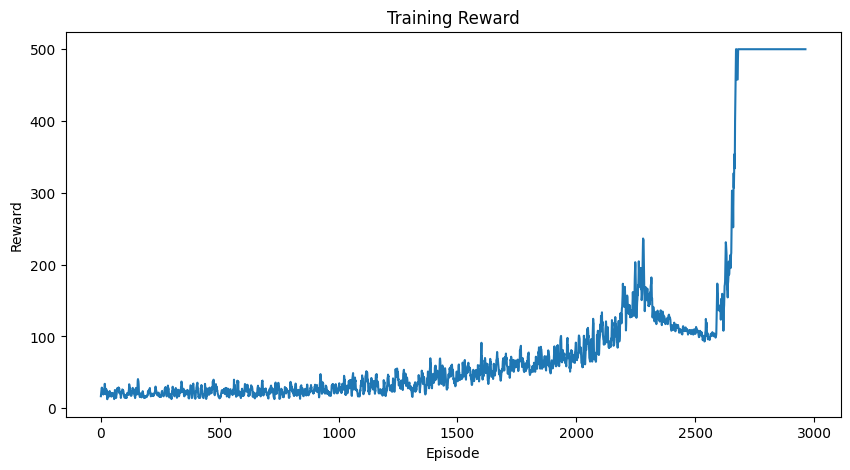

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
moving_average = np.convolve(np.array(rewards),np.ones(5) / 5,mode='valid')
plt.plot(moving_average)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training Reward")

plt.show()